# Does longer context help a small character-level transformer?

Daniel Moody (23370157) & Nandakishore Vinayakrishnan (23070854)

**Research question:** with training characters held fixed, does increasing context length from 32 to 128 to 256 lower test bits-per-character for a 4-layer character transformer on TinyShakespeare?

Baseline-gate pipeline: data, models, metric, training loop and both reference conditions. Use a T4 GPU runtime. The test split is not used here; it is scored once, after every run and decision is frozen.

In [1]:
import json
import math
import time
import urllib.request
from collections import Counter
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

DATA_URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
DATA_PATH = Path("data/input.txt")
RESULTS_DIR = Path("results")
RUNS_DIR = RESULTS_DIR / "runs"
CHECKPOINT_DIR = Path("checkpoints")
for directory in (DATA_PATH.parent, RUNS_DIR, CHECKPOINT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP = DEVICE == "cuda"
EVAL_START = 256

## 1. Data

TinyShakespeare is downloaded from Karpathy's char-rnn repository (MIT licence; the plays are public domain) and split contiguously 80/10/10. Each cut is moved forward to the next line break, so no line is split across sets. The vocabulary comes from the training split only, and any validation or test characters missing from it are reported.

In [2]:
if not DATA_PATH.exists():
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

text = DATA_PATH.read_text(encoding="utf-8")

def next_line_start(position):
    return text.index("\n", position) + 1

train_end = next_line_start(int(0.8 * len(text)))
val_end = next_line_start(int(0.9 * len(text)))
train_text, val_text, test_text = text[:train_end], text[train_end:val_end], text[val_end:]

vocab = sorted(set(train_text))
char_to_id = {char: i for i, char in enumerate(vocab)}
unseen_chars = {name: sorted(set(split) - set(vocab)) for name, split in [("val", val_text), ("test", test_text)]}

def encode(split_text):
    return torch.tensor([char_to_id[char] for char in split_text])

train_data, val_data, test_data = encode(train_text), encode(val_text), encode(test_text)
VOCAB_SIZE = len(vocab)

data_summary = {
    "total_chars": len(text),
    "split_chars": {"train": len(train_text), "val": len(val_text), "test": len(test_text)},
    "vocab_size": len(vocab),
    "unseen_chars": unseen_chars,
}
(RESULTS_DIR / "data_summary.json").write_text(json.dumps(data_summary, indent=2))
data_summary

{'total_chars': 1115394,
 'split_chars': {'train': 892324, 'val': 111532, 'test': 111538},
 'vocab_size': 65,
 'unseen_chars': {'val': [], 'test': []}}

In [ ]:
def get_kfold_splits(text, k=10, fold_idx=0):
    n = len(text)
    block_size = n // k

    val_start = (fold_idx * block_size) % n
    val_end = (val_start + block_size) % n

    test_start = val_end
    test_end = (test_start + block_size) % n

    if val_end > val_start and test_end > test_start:
        val_text = text[val_start:val_end]
        test_text = text[test_start:test_end]
        train_text = text[:val_start] + text[val_end:test_start] + text[test_end:]
    else:
        # Index wrapping
        val_text = text[val_start:val_start + block_size]
        test_text = text[val_start + block_size:val_start + 2*block_size]
        train_text = text[:val_start] + text[val_start + 2*block_size:]

    def align_to_line(t, pos):
        try:
            return t.index('\n', pos) + 1
        except ValueError:
            return pos

    return train_text, val_text, test_text

tr_t, va_t, te_t = get_kfold_splits(text, k=10, fold_idx=0)
print(f"Fold 0 - Train size: {len(tr_t)}, Val size: {len(va_t)}, Test size: {len(te_t)}")

## 2. Experiment settings

Only `context_len` changes between conditions. Every step sees 16,384 training characters, so the batch size is 512, 128 or 64.

In [3]:
@dataclass
class Config:
    context_len: int
    seed: int
    n_layer: int = 4
    n_head: int = 4
    n_embd: int = 192
    dropout: float = 0.1
    chars_per_step: int = 16384
    max_steps: int = 3000
    lr: float = 1e-3
    min_lr: float = 1e-4
    weight_decay: float = 0.1
    grad_clip: float = 1.0
    eval_interval: int = 250
    eval_batches: int = 20

    @property
    def batch_size(self):
        return self.chars_per_step // self.context_len

    @property
    def run_name(self):
        return f"ctx{self.context_len}_seed{self.seed}"

## 3. Transformer

A GPT-style decoder: pre-LayerNorm blocks, causal self-attention, a GELU MLP, learned position embeddings, and output weights tied to the token embeddings.

The position table is created last, and the seed is reset just before the weights are initialised. With the same seed, every weight except the position table therefore starts identical at every context length.

In [4]:
class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.n_head = config.n_head
        self.qkv = nn.Linear(config.n_embd, 3 * config.n_embd)
        self.out = nn.Linear(config.n_embd, config.n_embd)
        self.attn_dropout = config.dropout
        self.resid_dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        batch, length, width = x.shape
        q, k, v = (t.view(batch, length, self.n_head, -1).transpose(1, 2) for t in self.qkv(x).split(width, dim=2))
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True, dropout_p=self.attn_dropout if self.training else 0.0)
        return self.resid_dropout(self.out(y.transpose(1, 2).reshape(batch, length, width)))


class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.attn_norm = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.mlp_norm = nn.LayerNorm(config.n_embd)
        self.mlp = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.GELU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.attn_norm(x))
        return x + self.mlp(self.mlp_norm(x))


def init_weights(module):
    if isinstance(module, (nn.Linear, nn.Embedding)):
        nn.init.normal_(module.weight, std=0.02)
    if isinstance(module, nn.Linear) and module.bias is not None:
        nn.init.zeros_(module.bias)


class CharTransformer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.token_embedding = nn.Embedding(VOCAB_SIZE, config.n_embd)
        self.embedding_dropout = nn.Dropout(config.dropout)
        self.blocks = nn.Sequential(*[Block(config) for _ in range(config.n_layer)])
        self.final_norm = nn.LayerNorm(config.n_embd)
        self.head = nn.Linear(config.n_embd, VOCAB_SIZE, bias=False)
        self.head.weight = self.token_embedding.weight
        self.position_embedding = nn.Embedding(config.context_len, config.n_embd)
        torch.manual_seed(config.seed)
        self.apply(init_weights)

    def forward(self, ids):
        positions = torch.arange(ids.size(1), device=ids.device)
        x = self.embedding_dropout(self.token_embedding(ids) + self.position_embedding(positions))
        return self.head(self.final_norm(self.blocks(x)))

    def num_params(self):
        return sum(p.numel() for p in self.parameters())

In [5]:
for context_len in [32, 128, 256]:
    print(f"context {context_len}: {CharTransformer(Config(context_len, seed=0)).num_params():,} parameters")

short_model = CharTransformer(Config(32, seed=0)).state_dict()
long_model = CharTransformer(Config(256, seed=0)).state_dict()
assert all(torch.equal(short_model[name], long_model[name]) for name in short_model if name != "position_embedding.weight")
print("Same seed gives identical starting weights apart from the position table")

context 32: 1,798,464 parameters
context 128: 1,816,896 parameters
context 256: 1,841,472 parameters
Same seed gives identical starting weights apart from the position table


## 4. N-gram

A character n-gram with interpolated absolute-discounting smoothing. For a history *h* and next character *c*:

P_n(c | h) = max(count(h, c) − d, 0) / count(h) + d · types(h) / count(h) · P_{n−1}(c | shorter h)

types(h) is the number of distinct characters seen after *h*. Histories never seen in training fall back fully to the shorter history. The unigram level uses add-one smoothing, so no character gets probability zero.

In [6]:
class NgramModel:
    def __init__(self, text, max_order):
        self.max_order = max_order
        self.unigram_counts = Counter(text)
        self.total_chars = len(text)
        self.ngram_counts, self.history_counts, self.history_types = {}, {}, {}
        for order in range(2, max_order + 1):
            ngrams = Counter(text[i:i + order] for i in range(len(text) - order + 1))
            history_counts, history_types = Counter(), Counter()
            for ngram, count in ngrams.items():
                history_counts[ngram[:-1]] += count
                history_types[ngram[:-1]] += 1
            self.ngram_counts[order] = ngrams
            self.history_counts[order] = history_counts
            self.history_types[order] = history_types

    def probability_by_order(self, history, char, discount):
        probability = (self.unigram_counts[char] + 1) / (self.total_chars + VOCAB_SIZE)
        probabilities = [probability]
        for order in range(2, self.max_order + 1):
            context = history[-(order - 1):]
            history_count = self.history_counts[order][context]
            if history_count:
                discounted = max(self.ngram_counts[order][context + char] - discount, 0) / history_count
                backoff_weight = discount * self.history_types[order][context] / history_count
                probability = discounted + backoff_weight * probability
            probabilities.append(probability)
        return probabilities

## 5. Metric: fixed-target bits-per-character

Every model scores the same targets: every character from position 257 of a split onward. A model with context length L predicts each target from the L characters before it, and only the last position of each window is scored. BPC = cross-entropy in nats / ln 2.

In [7]:
def ngram_bpc_by_order(model, split_text, discount):
    bits = np.zeros(model.max_order)
    for t in range(EVAL_START, len(split_text)):
        history = split_text[t - model.max_order + 1:t]
        bits -= np.log2(model.probability_by_order(history, split_text[t], discount))
    return bits / (len(split_text) - EVAL_START)


@torch.no_grad()
def transformer_bpc(model, data, context_len, batch_size=512):
    model.eval()
    targets = torch.arange(EVAL_START, len(data))
    window = torch.arange(-context_len, 0)
    total_nats = 0.0
    for batch_targets in targets.split(batch_size):
        logits = model(data[batch_targets[:, None] + window].to(DEVICE))[:, -1]
        total_nats += F.cross_entropy(logits, data[batch_targets].to(DEVICE), reduction="sum").item()
    return total_nats / len(targets) / math.log(2)

## 6. Reference condition 1: n-gram

Order (1–8) and discount *d* are chosen by validation BPC. The model is deterministic, so it needs only one run.

In [8]:
ngram = NgramModel(train_text, max_order=8)

ngram_grid = []
for discount in [0.5, 0.75, 0.9]:
    for order, bpc in enumerate(ngram_bpc_by_order(ngram, val_text, discount), start=1):
        ngram_grid.append({"order": order, "discount": discount, "val_bpc": float(bpc)})

best_ngram = min(ngram_grid, key=lambda row: row["val_bpc"])
(RESULTS_DIR / "ngram.json").write_text(json.dumps({"best": best_ngram, "grid": ngram_grid}, indent=2))
best_ngram

{'order': 5, 'discount': 0.9, 'val_bpc': 2.360153280898408}

## 7. Training loop

AdamW with a cosine learning-rate schedule from 1e-3 down to 1e-4, gradient clipping at 1.0, and fp16 mixed precision on GPU. Every `eval_interval` steps the loop:

- estimates the validation loss on a fixed set of validation batches;
- keeps the checkpoint with the lowest validation loss as `best.pt`;
- saves the full training state to `last.pt`, so a run that disconnects picks up where it stopped.

In [9]:
def get_batch(data, context_len, batch_size, generator):
    starts = torch.randint(len(data) - context_len, (batch_size,), generator=generator)
    positions = starts[:, None] + torch.arange(context_len)
    return data[positions].to(DEVICE), data[positions + 1].to(DEVICE)


def loss_on(model, inputs, targets):
    with torch.autocast(DEVICE, dtype=torch.float16, enabled=USE_AMP):
        logits = model(inputs)
    return F.cross_entropy(logits.flatten(0, 1).float(), targets.flatten())


@torch.no_grad()
def validation_loss(model, config):
    model.eval()
    generator = torch.Generator().manual_seed(0)
    losses = [loss_on(model, *get_batch(val_data, config.context_len, config.batch_size, generator)).item()
              for _ in range(config.eval_batches)]
    model.train()
    return sum(losses) / len(losses)


def train(config):
    run_dir = CHECKPOINT_DIR / config.run_name
    run_dir.mkdir(parents=True, exist_ok=True)
    last_path, best_path = run_dir / "last.pt", run_dir / "best.pt"

    model = CharTransformer(config).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.max_steps, eta_min=config.min_lr)
    scaler = torch.amp.GradScaler(enabled=USE_AMP)
    batch_generator = torch.Generator().manual_seed(config.seed)
    progress = {"step": 0, "best_step": 0, "best_val_loss": math.inf, "train_seconds": 0.0, "history": []}

    if last_path.exists():
        checkpoint = torch.load(last_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(checkpoint["model"])
        optimizer.load_state_dict(checkpoint["optimizer"])
        scheduler.load_state_dict(checkpoint["scheduler"])
        scaler.load_state_dict(checkpoint["scaler"])
        batch_generator.set_state(checkpoint["batch_generator"])
        progress = checkpoint["progress"]
        print(f"Resuming {config.run_name} from step {progress['step']}")

    torch.manual_seed(config.seed + progress["step"])
    model.train()
    start_time, recent_losses = time.time(), []
    for step in range(progress["step"] + 1, config.max_steps + 1):
        loss = loss_on(model, *get_batch(train_data, config.context_len, config.batch_size, batch_generator))
        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        recent_losses.append(loss.item())

        if step % config.eval_interval == 0:
            val_loss = validation_loss(model, config)
            progress["history"].append({"step": step, "train_loss": sum(recent_losses) / len(recent_losses), "val_loss": val_loss})
            recent_losses = []
            if val_loss < progress["best_val_loss"]:
                progress.update(best_step=step, best_val_loss=val_loss)
                torch.save(model.state_dict(), best_path)
            progress["step"] = step
            progress["train_seconds"] += time.time() - start_time
            start_time = time.time()
            torch.save({
                "model": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(),
                "scaler": scaler.state_dict(),
                "batch_generator": batch_generator.get_state(),
                "progress": progress,
            }, last_path)
            print(f"step {step:5d} | train {progress['history'][-1]['train_loss']:.4f} | val {val_loss:.4f} "
                  f"| best {progress['best_val_loss']:.4f} @ {progress['best_step']}")

    run_record = {
        "config": asdict(config),
        "batch_size": config.batch_size,
        "num_params": model.num_params(),
        "device": torch.cuda.get_device_name() if DEVICE == "cuda" else "cpu",
        "torch_version": torch.__version__,
        **progress,
    }
    (RUNS_DIR / f"{config.run_name}.json").write_text(json.dumps(run_record, indent=2))
    return run_record

## 8. Reference condition 2: context-32 transformer, seed 0

In [10]:
reference_run = train(Config(context_len=32, seed=0))
print(f"best validation loss {reference_run['best_val_loss']:.4f} at step {reference_run['best_step']}, "
      f"{reference_run['train_seconds'] / 60:.1f} min on {reference_run['device']}")

step   250 | train 2.2839 | val 1.8862 | best 1.8862 @ 250
step   500 | train 1.7086 | val 1.6675 | best 1.6675 @ 500
step   750 | train 1.5532 | val 1.5897 | best 1.5897 @ 750
step  1000 | train 1.4825 | val 1.5554 | best 1.5554 @ 1000
step  1250 | train 1.4379 | val 1.5353 | best 1.5353 @ 1250
step  1500 | train 1.4055 | val 1.5182 | best 1.5182 @ 1500
step  1750 | train 1.3825 | val 1.5102 | best 1.5102 @ 1750
step  2000 | train 1.3636 | val 1.5036 | best 1.5036 @ 2000
step  2250 | train 1.3490 | val 1.5003 | best 1.5003 @ 2250
step  2500 | train 1.3347 | val 1.4954 | best 1.4954 @ 2500
step  2750 | train 1.3259 | val 1.4899 | best 1.4899 @ 2750
step  3000 | train 1.3198 | val 1.4908 | best 1.4899 @ 2750
best validation loss 1.4899 at step 2750, 1.7 min on Tesla T4


## 9. Validation results

Every finished run's selected checkpoint, scored with the fixed-target metric on validation.

In [11]:
runs = [json.loads(path.read_text()) for path in sorted(RUNS_DIR.glob("*.json"))]

rows = []
for run in runs:
    config = Config(**run["config"])
    model = CharTransformer(config).to(DEVICE)
    model.load_state_dict(torch.load(CHECKPOINT_DIR / config.run_name / "best.pt", map_location=DEVICE))
    rows.append({
        "model": "transformer",
        "context_len": config.context_len,
        "seed": config.seed,
        "best_step": run["best_step"],
        "train_minutes": round(run["train_seconds"] / 60, 1),
        "val_bpc": transformer_bpc(model, val_data, config.context_len),
    })

best_ngram = json.loads((RESULTS_DIR / "ngram.json").read_text())["best"]
rows.append({"model": f"{best_ngram['order']}-gram (d={best_ngram['discount']})", "val_bpc": best_ngram["val_bpc"]})

results = pd.DataFrame(rows)
results.to_csv(RESULTS_DIR / "validation_results.csv", index=False)
results

,model,context_len,seed,best_step,train_minutes,val_bpc
0,transformer,32.0,0.0,2750.0,1.7,2.027949
1,5-gram (d=0.9),NaN,NaN,NaN,NaN,2.360153


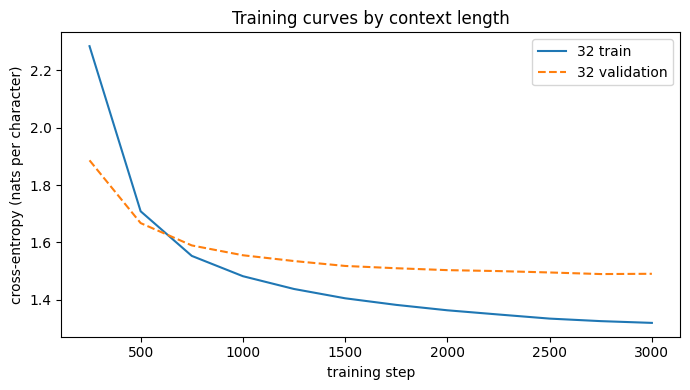

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
for run in runs:
    steps = [point["step"] for point in run["history"]]
    ax.plot(steps, [point["train_loss"] for point in run["history"]], label=f"{run['config']['context_len']} train")
    ax.plot(steps, [point["val_loss"] for point in run["history"]], "--", label=f"{run['config']['context_len']} validation")
ax.set_xlabel("training step")
ax.set_ylabel("cross-entropy (nats per character)")
ax.set_title("Training curves by context length")
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "training_curves.png", dpi=150)